In [1]:
print("setup works")

setup works


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Pull FTSE 100 index data
ftse = yf.download("^FTSE", start="2015-01-01", end="2026-08-01")
ftse.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,
2015-01-02,6547.799805,6607.899902,6510.600098,6566.100098,367562200
2015-01-05,6417.200195,6576.700195,6404.500000,6547.799805,728001100
2015-01-06,6366.500000,6452.700195,6328.600098,6417.200195,769463100
2015-01-07,6419.799805,6459.700195,6366.500000,6366.500000,688211500
2015-01-08,6570.000000,6580.799805,6419.799805,6419.799805,882740200


In [3]:
# Flattening the MultiIndex columns yfinance outputs
ftse.columns = ftse.columns.get_level_values(0)
ftse.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,6547.799805,6607.899902,6510.600098,6566.100098,367562200
2015-01-05,6417.200195,6576.700195,6404.500000,6547.799805,728001100
2015-01-06,6366.500000,6452.700195,6328.600098,6417.200195,769463100
2015-01-07,6419.799805,6459.700195,6366.500000,6366.500000,688211500
2015-01-08,6570.000000,6580.799805,6419.799805,6419.799805,882740200


In [4]:
# Pulling S&P 500 index data
sp500 = yf.download("^GSPC", start="2015-01-01", end="2026-08-01")
sp500.columns = sp500.columns.get_level_values(0)
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


In [5]:
print("FTSE shape:", ftse.shape)
print("FTSE date range:", ftse.index.min(), "to", ftse.index.max())
print("Missing values in FTSE:\n", ftse.isnull().sum())

print("\nS&P 500 shape:", sp500.shape)
print("S&P 500 date range:", sp500.index.min(), "to", sp500.index.max())
print("Missing values in S&P 500:\n", sp500.isnull().sum())

FTSE shape: (2925, 5)
FTSE date range: 2015-01-02 00:00:00 to 2026-07-31 00:00:00
Missing values in FTSE:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

S&P 500 shape: (2911, 5)
S&P 500 date range: 2015-01-02 00:00:00 to 2026-07-31 00:00:00
Missing values in S&P 500:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


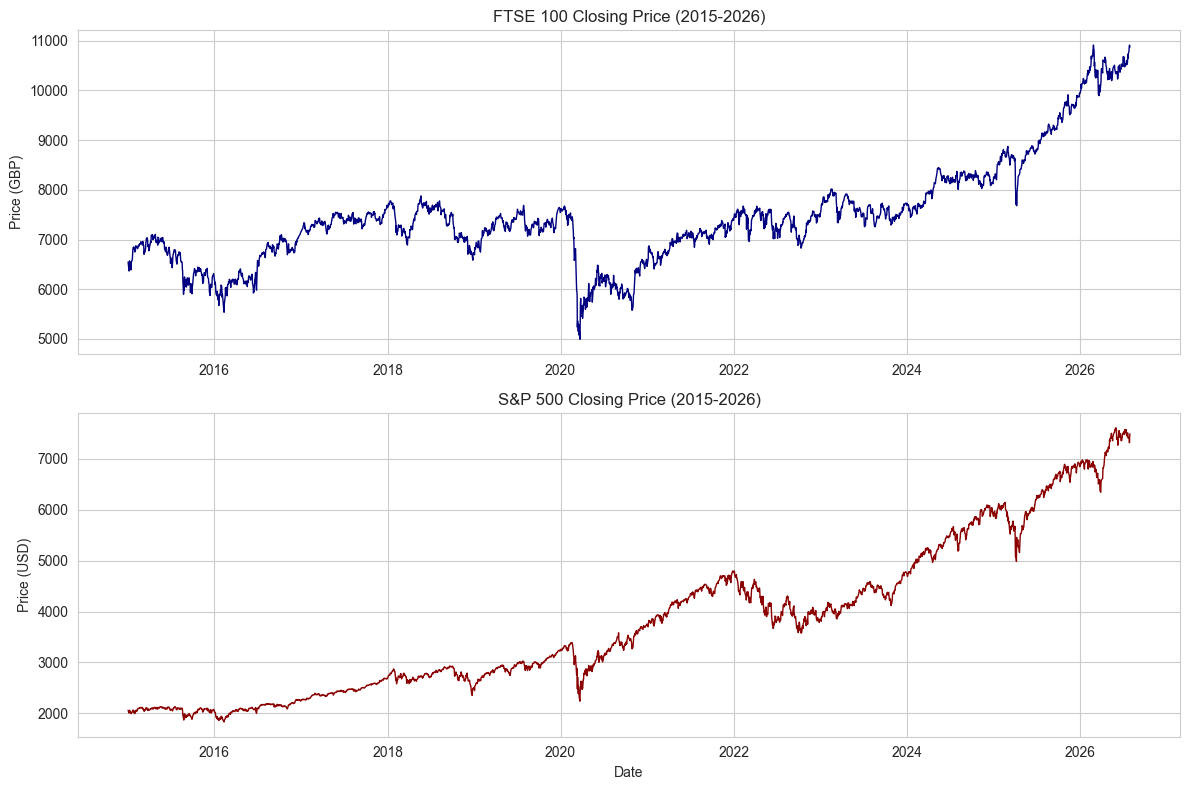

In [7]:
#visualizing the price series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(ftse.index, ftse['Close'], color='navy', linewidth=1)
axes[0].set_title('FTSE 100 Closing Price (2015-2026)')
axes[0].set_ylabel('Price (GBP)')

axes[1].plot(sp500.index, sp500['Close'], color='darkred', linewidth=1)
axes[1].set_title('S&P 500 Closing Price (2015-2026)')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [8]:
# Compute log returns
ftse['log_return'] = np.log(ftse['Close'] / ftse['Close'].shift(1))
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1))

# Drop the first row (NaN from the shift)
ftse = ftse.dropna(subset=['log_return'])
sp500 = sp500.dropna(subset=['log_return'])

ftse[['Close', 'log_return']].head()

Price,Close,log_return
Date,,
2015-01-05,6417.200195,-0.020147
2015-01-06,6366.500000,-0.007932
2015-01-07,6419.799805,0.008337
2015-01-08,6570.000000,0.023127
2015-01-09,6501.100098,-0.010542


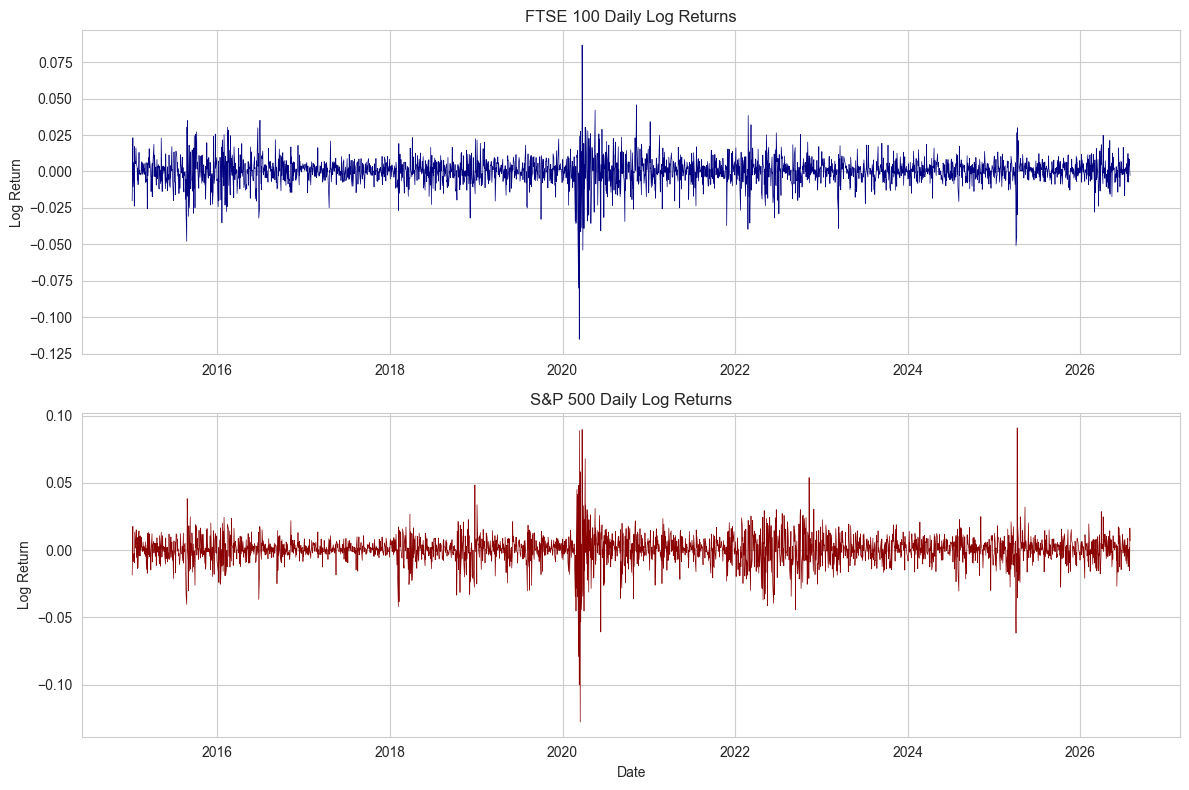

In [9]:
#plotting returns series

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(ftse.index, ftse['log_return'], color='navy', linewidth=0.5)
axes[0].set_title('FTSE 100 Daily Log Returns')
axes[0].set_ylabel('Log Return')

axes[1].plot(sp500.index, sp500['log_return'], color='darkred', linewidth=0.5)
axes[1].set_title('S&P 500 Daily Log Returns')
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [10]:
# Rolling volatility: standard deviation of returns over a trailing window
# 21 trading days ≈ 1 calendar month — the standard convention in finance

ftse['volatility_21d'] = ftse['log_return'].rolling(window=21).std()
sp500['volatility_21d'] = sp500['log_return'].rolling(window=21).std()

# Annualize it (multiply by sqrt of trading days per year) — makes the number interpretable
ftse['volatility_annualized'] = ftse['volatility_21d'] * np.sqrt(252)
sp500['volatility_annualized'] = sp500['volatility_21d'] * np.sqrt(252)

ftse[['log_return', 'volatility_21d', 'volatility_annualized']].tail(10)

Price,log_return,volatility_21d,volatility_annualized
Date,,,
2026-07-20,-0.007157,0.006243,0.099106
2026-07-21,0.005789,0.006179,0.098084
2026-07-22,0.012308,0.006665,0.105799
2026-07-23,-0.007286,0.006905,0.109610
2026-07-24,0.009076,0.007032,0.111637
2026-07-27,0.004238,0.007033,0.111639
2026-07-28,0.008239,0.007145,0.113417
2026-07-29,0.003434,0.007153,0.113552
2026-07-30,-0.001018,0.007135,0.113272


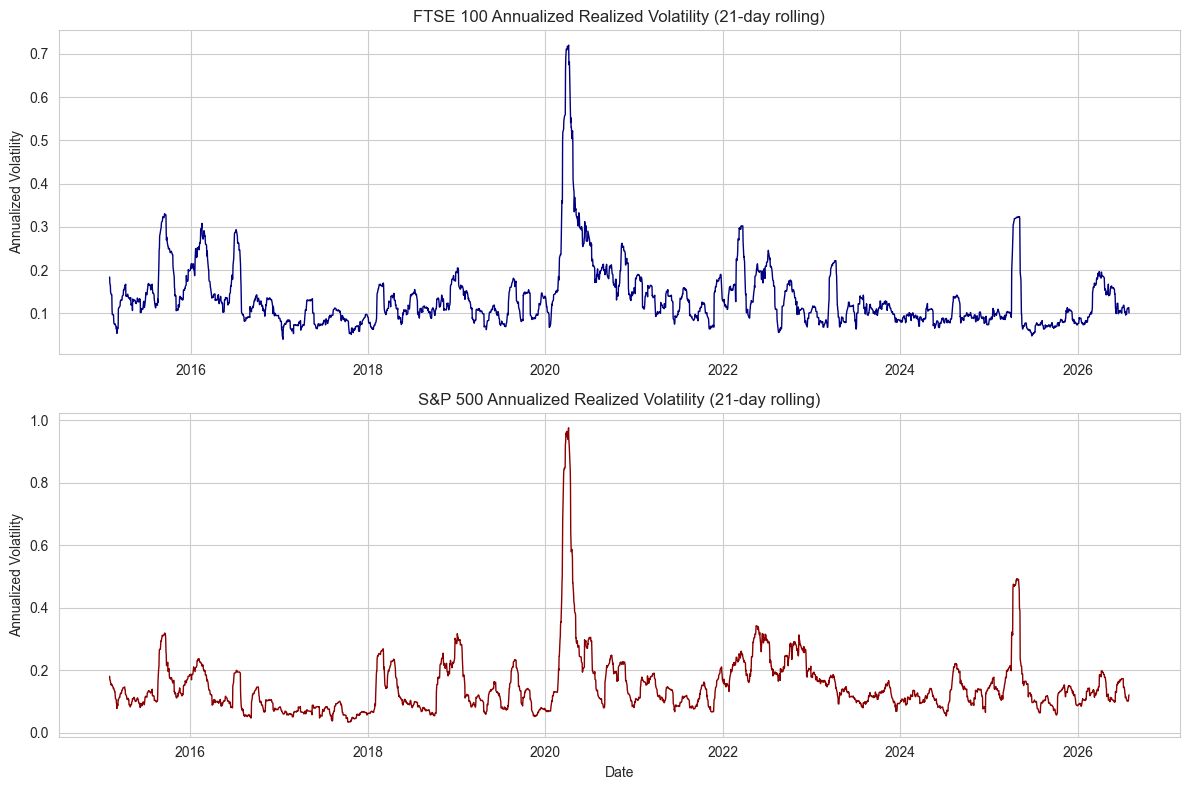

In [11]:
#plotting realized volatility series

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(ftse.index, ftse['volatility_annualized'], color='navy', linewidth=1)
axes[0].set_title('FTSE 100 Annualized Realized Volatility (21-day rolling)')
axes[0].set_ylabel('Annualized Volatility')

axes[1].plot(sp500.index, sp500['volatility_annualized'], color='darkred', linewidth=1)
axes[1].set_title('S&P 500 Annualized Realized Volatility (21-day rolling)')
axes[1].set_ylabel('Annualized Volatility')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


In [12]:
#Stationarity tests: Augmented Dickey-Fuller (ADF) test

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print('Result: Stationary (reject null hypothesis)\n')
    else:
        print('Result: Non-stationary (fail to reject null hypothesis)\n')

adf_test(ftse['Close'], 'FTSE 100 Price')
adf_test(ftse['log_return'], 'FTSE 100 Log Return')
adf_test(sp500['Close'], 'S&P 500 Price')
adf_test(sp500['log_return'], 'S&P 500 Log Return')

--- ADF Test: FTSE 100 Price ---
ADF Statistic: -0.3411
p-value: 0.9195
Result: Non-stationary (fail to reject null hypothesis)

--- ADF Test: FTSE 100 Log Return ---
ADF Statistic: -11.9411
p-value: 0.0000
Result: Stationary (reject null hypothesis)

--- ADF Test: S&P 500 Price ---
ADF Statistic: 1.0260
p-value: 0.9945
Result: Non-stationary (fail to reject null hypothesis)

--- ADF Test: S&P 500 Log Return ---
ADF Statistic: -17.4353
p-value: 0.0000
Result: Stationary (reject null hypothesis)



In [13]:
import os
os.makedirs('data', exist_ok=True)

ftse.to_csv('data/ftse_processed.csv')
sp500.to_csv('data/sp500_processed.csv')
print("Saved processed data.")

Saved processed data.
